In [ ]:
import os
FIG_ROOT = os.environ.get('SCDIS_FIG', os.path.join(os.environ['SCDIS_ROOT'], 'figures'))

In [1]:
import scanpy as sc
import scipy.sparse as sp
import numpy as np
import umap

2026-03-02 06:37:23.510682: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-02 06:37:23.524860: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-02 06:37:23.524877: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-02 06:37:23.534610: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-02 06:37:24.154643: W tensorflow/compiler/tf

In [2]:
import matplotlib
import matplotlib.ticker as ticker
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Liberation Sans'
matplotlib.rcParams['mathtext.default'] = 'regular'
matplotlib.rcParams['axes.unicode_minus'] = False

In [3]:
cell_type_key = 'cell_type'
dataset_name = 'kang'

# Read data

In [4]:
adata = sc.read_h5ad('adata_structured_balanced.h5ad')
adata_org = sc.read_h5ad(
    f'{os.environ["SCDIS_ROOT"]}/Datasets/preprocessed_datasets/{dataset_name}.h5ad'
)
adata.var_names = adata_org.var_names.copy()
adata.obs['level_cat'] = adata.obs['level'].astype('category')

/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


# Normalize

In [5]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# UMAP

In [6]:
adata_all = sc.read_h5ad('adata_structured_unbalanced.h5ad')
adata_all.var_names = adata_org.var_names.tolist()

sc.pp.normalize_total(adata_all, target_sum=1e4)
sc.pp.log1p(adata_all)

/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [7]:
max_level = adata_all.obs['level'].max()
max_level

16

In [8]:
last_level_latent = adata_all[
    adata_all.obs['level'] == max_level
    ].obsm['mapped_latent'].copy()

last_level_latent.shape

# UMAP on last level
umap_model = umap.UMAP(n_components=2, random_state=1)

umap_model.fit(last_level_latent)

# Infer on all other levels
X_umap = umap_model.transform(adata_all.obsm['mapped_latent'])

# Store the result in adata_cat
adata_all.obsm['X_umap_fit'] = X_umap

/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


# Visualize UMAPs and heatmaps

In [9]:
genes_to_plot = {
    'GZMB': ['CD8 T', 'NK'],
    'PRF1': ['CD8 T', 'NK'],
    'MEF2C':  [('CD8 T', 'CD4 T', 'T')],
    'HLA-DRA': ['DC'],
    'FCGR3A': ['DC', 'CD14 Mono', 'CD16 Mono'],
    'MS4A7': ['DC', 'CD14 Mono', 'CD16 Mono'],
    'S100A8': ['DC', 'CD14 Mono', 'CD16 Mono'],
    'S100A9': ['DC', 'CD14 Mono', 'CD16 Mono'],
    # mature
    'NKG7': ['CD8 T'], # mature
    'IFNG': ['CD8 T'], # mature
}

In [10]:
import os
import matplotlib.pyplot as plt

/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/scanpy/plotting/_utils.py:1241: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=ax_or_figsize)


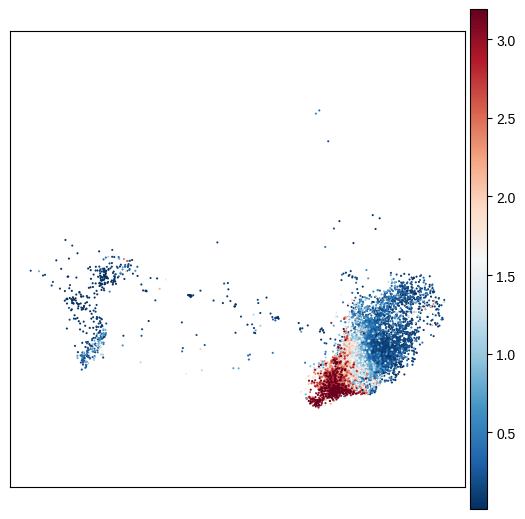

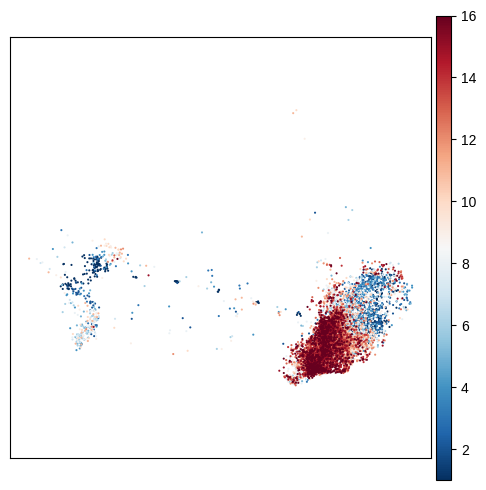

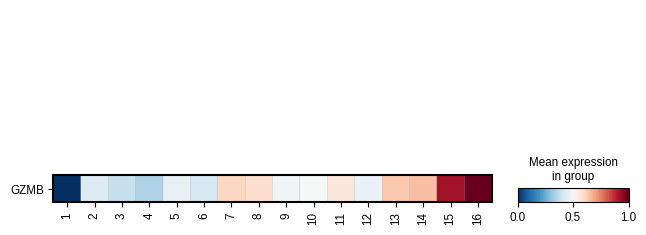

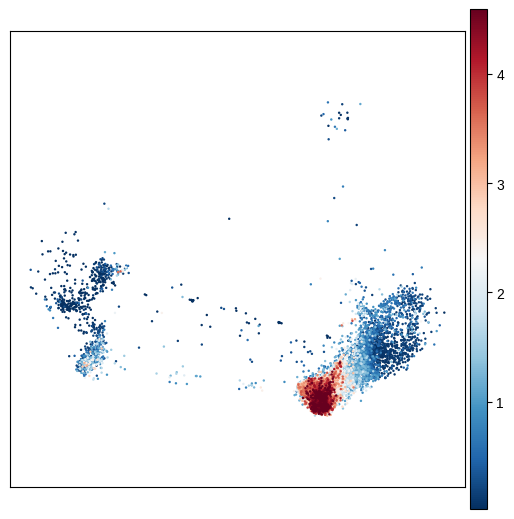

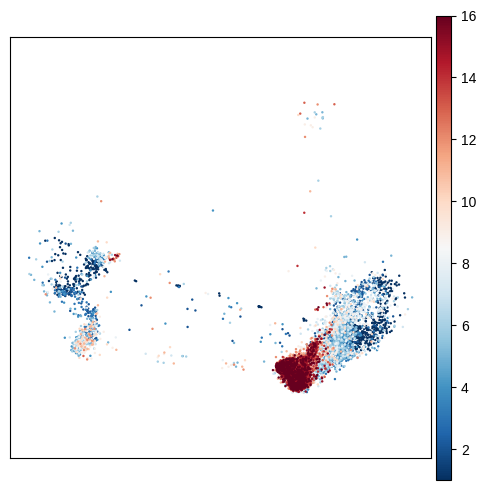

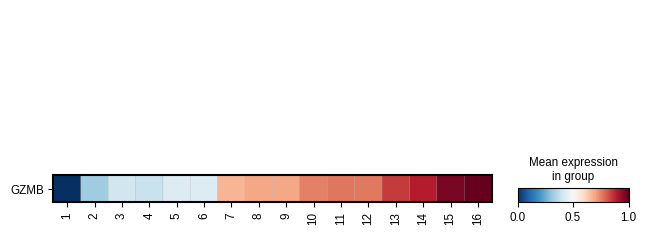

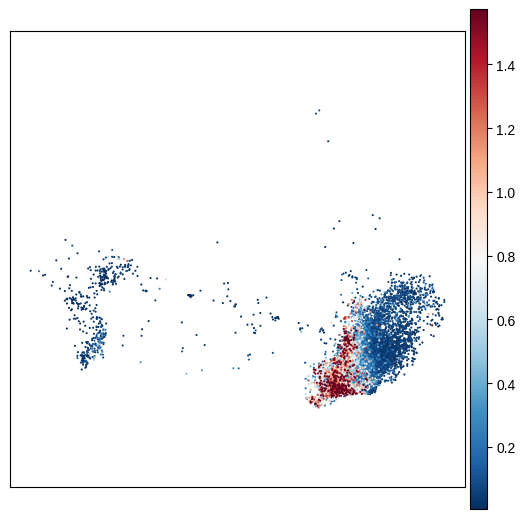

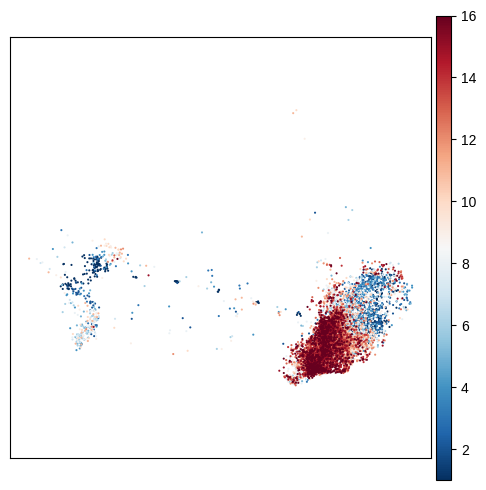

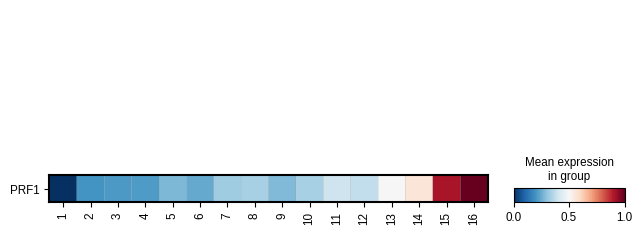

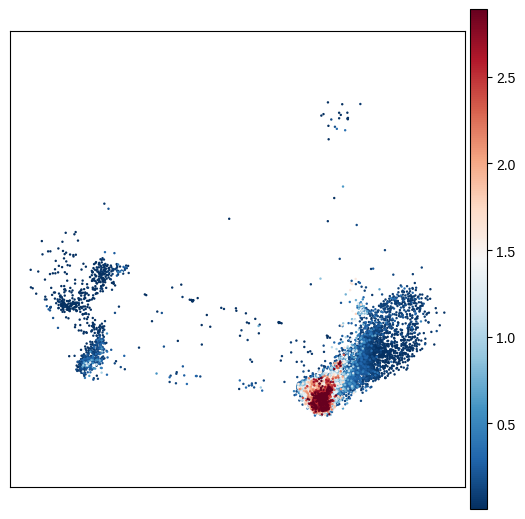

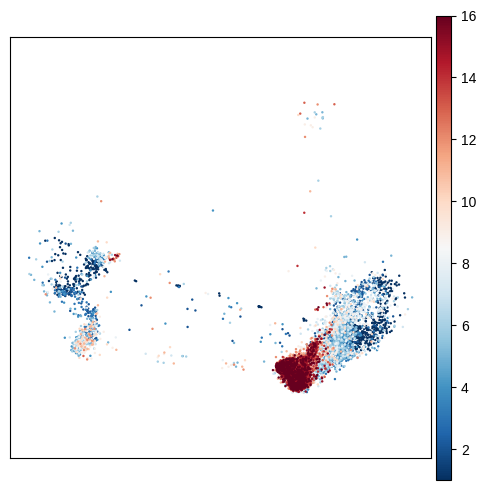

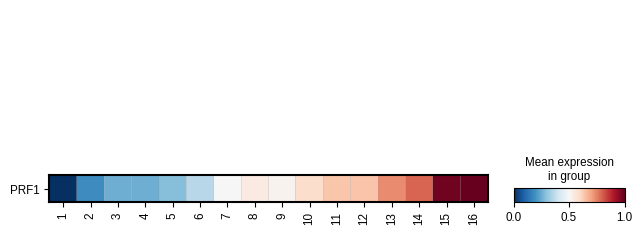

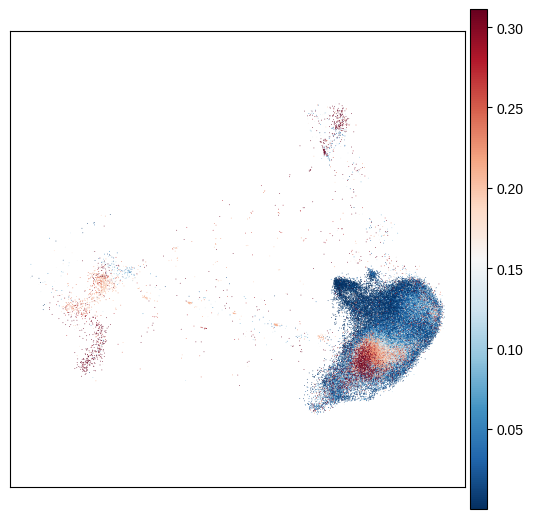

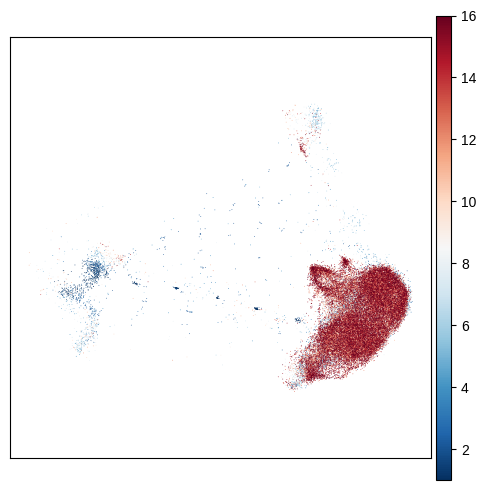

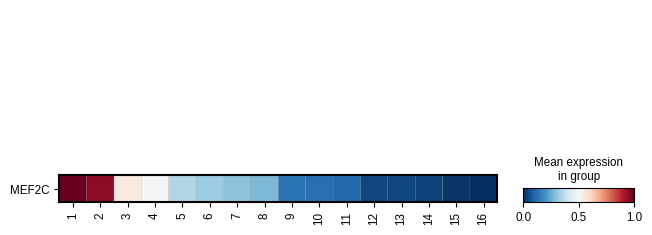

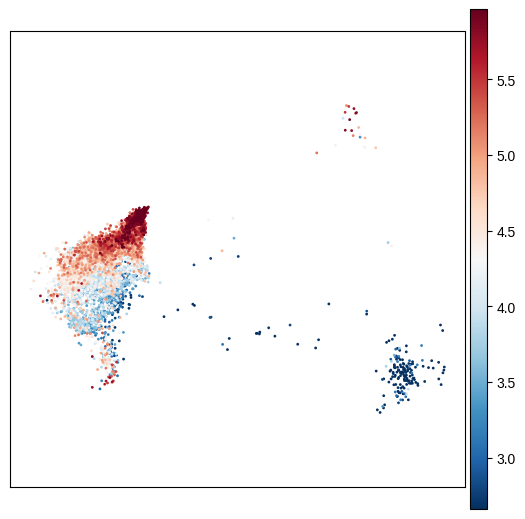

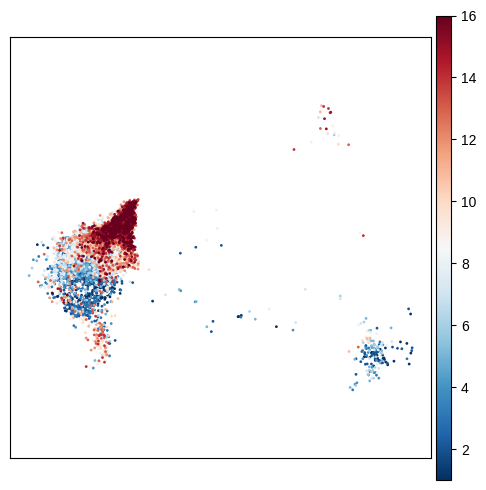

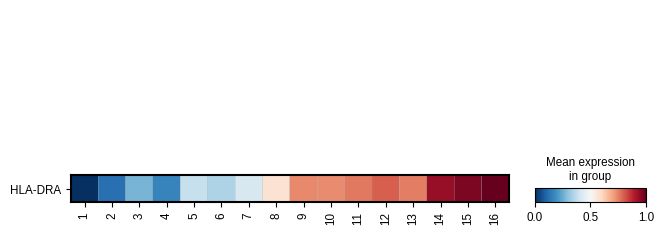

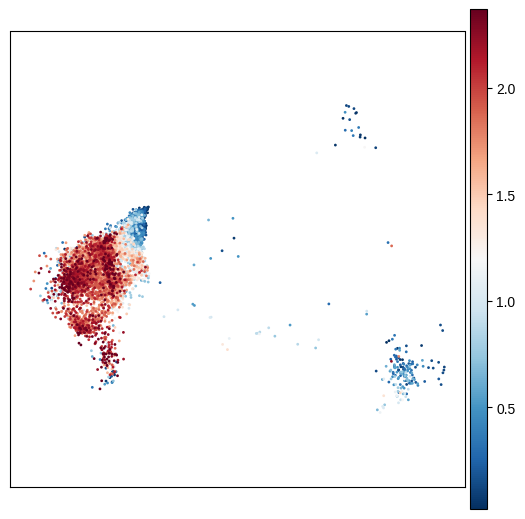

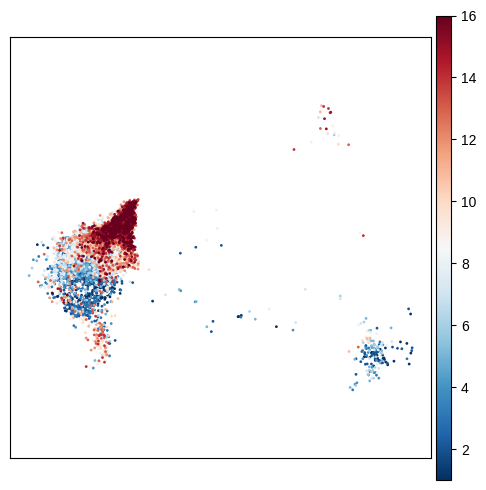

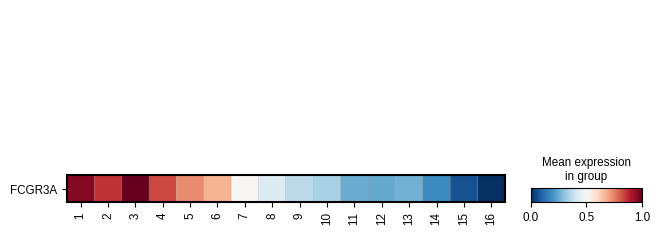

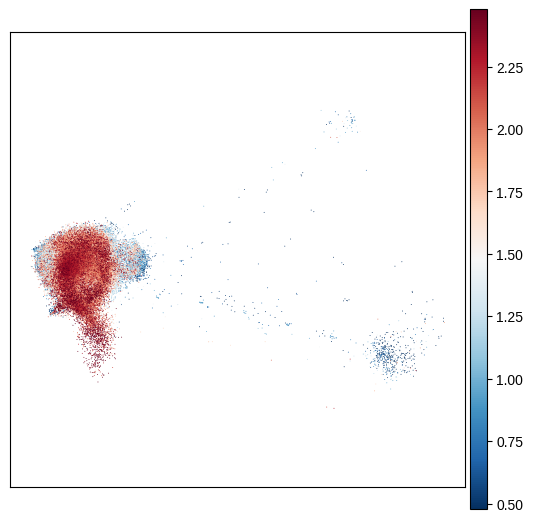

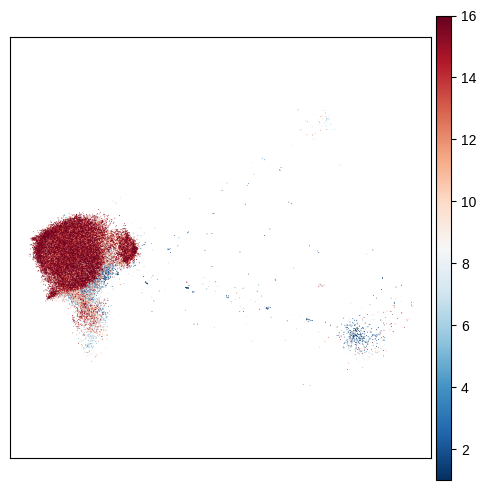

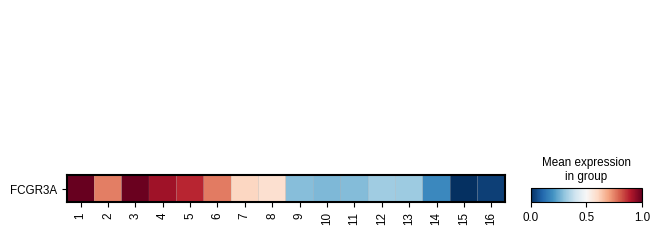

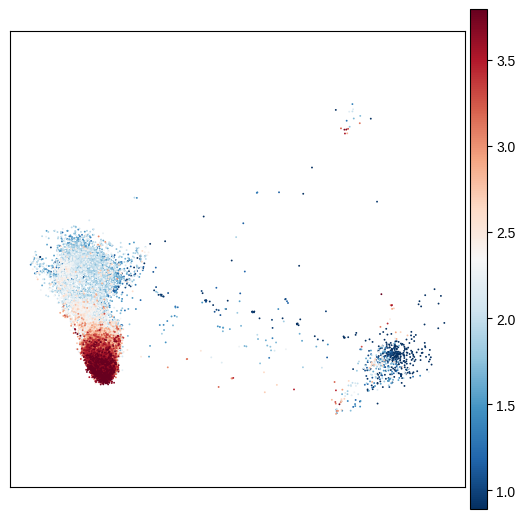

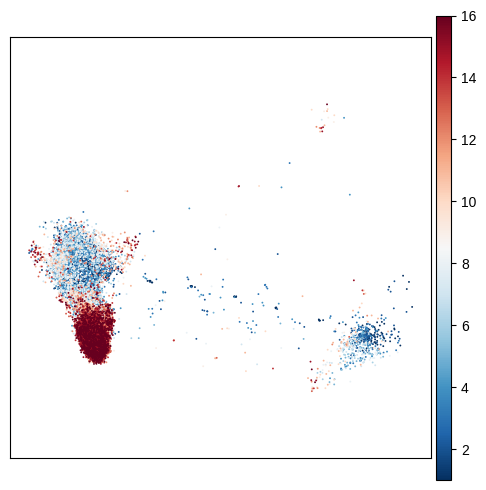

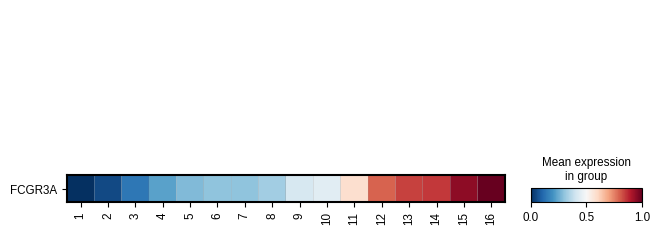

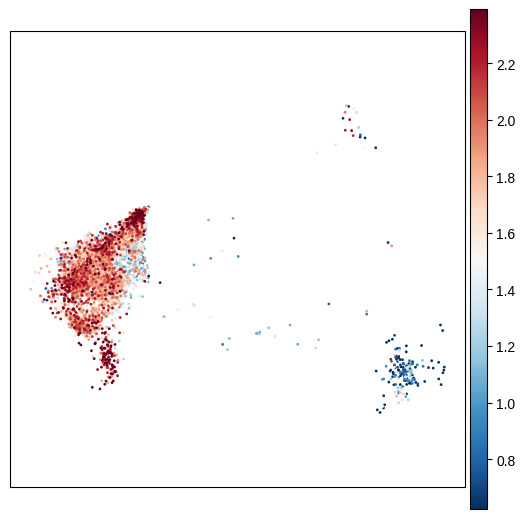

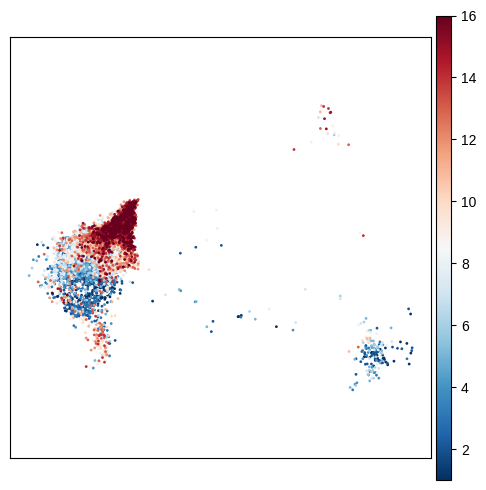

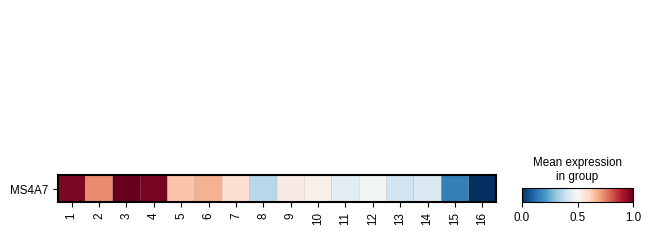

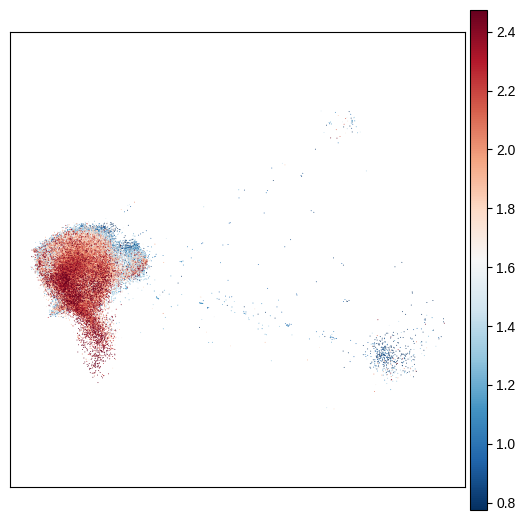

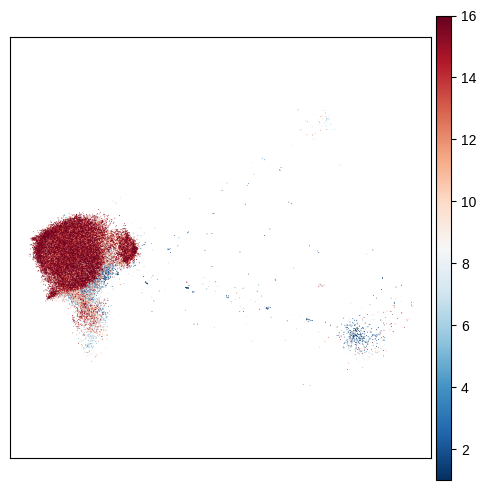

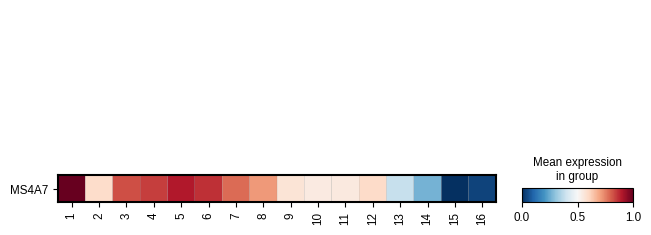

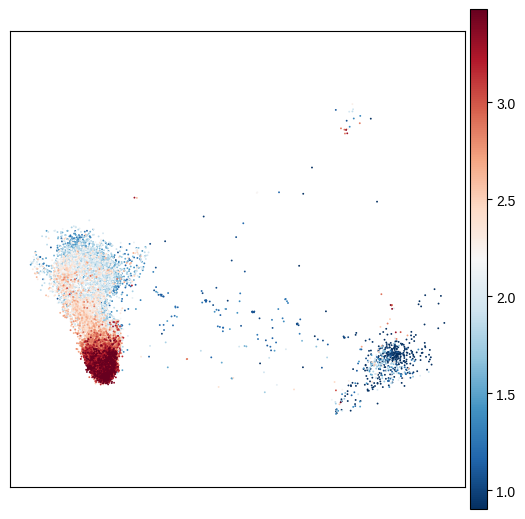

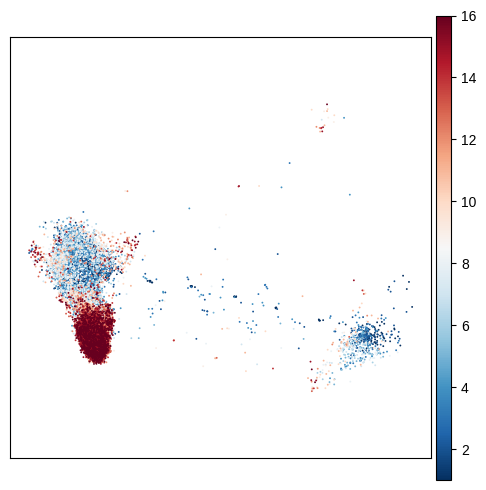

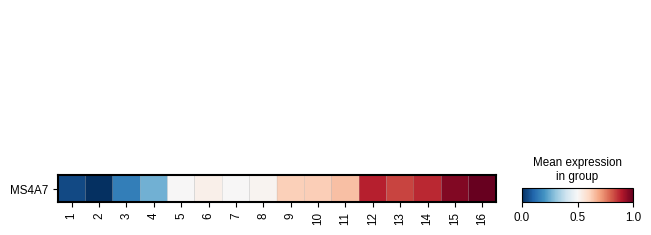

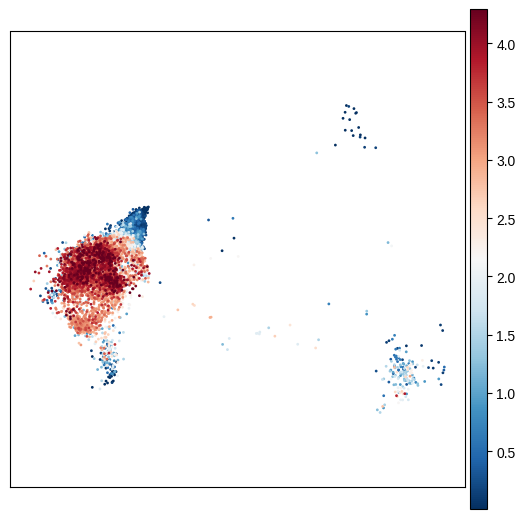

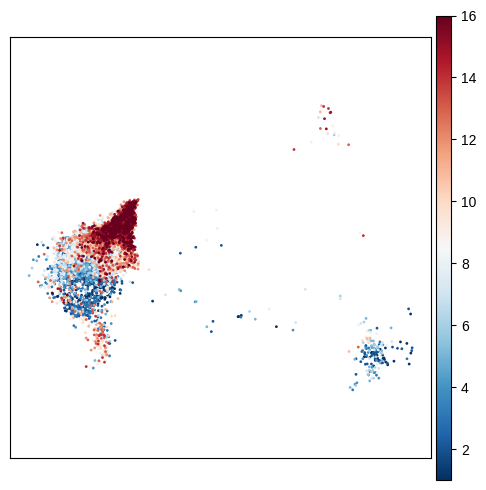

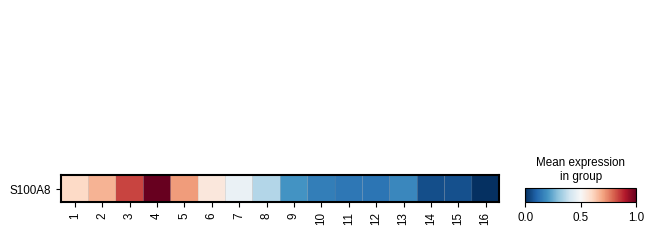

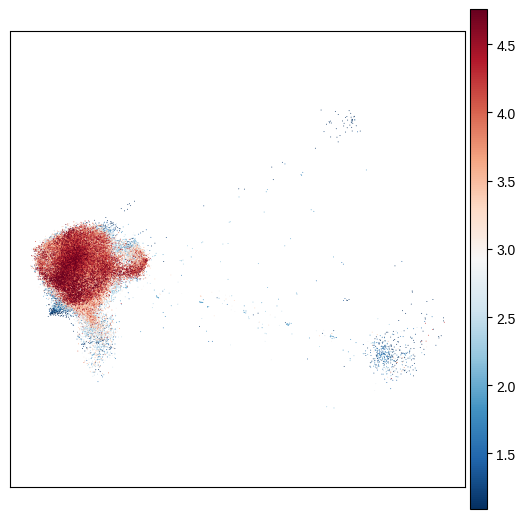

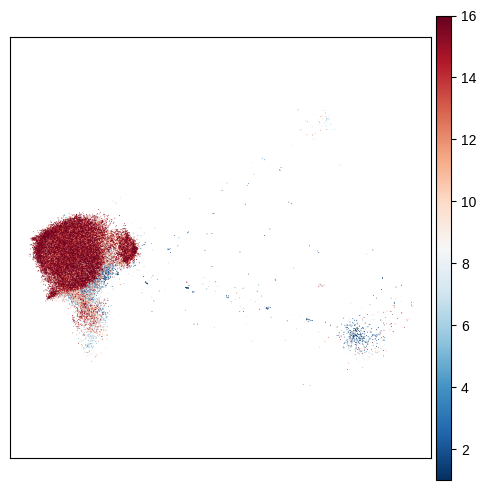

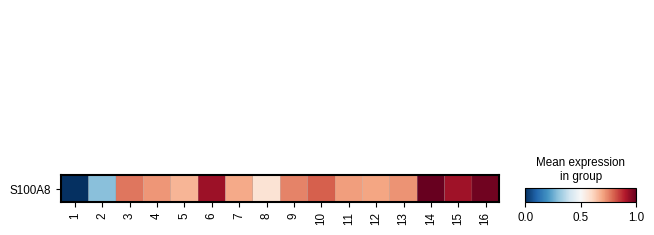

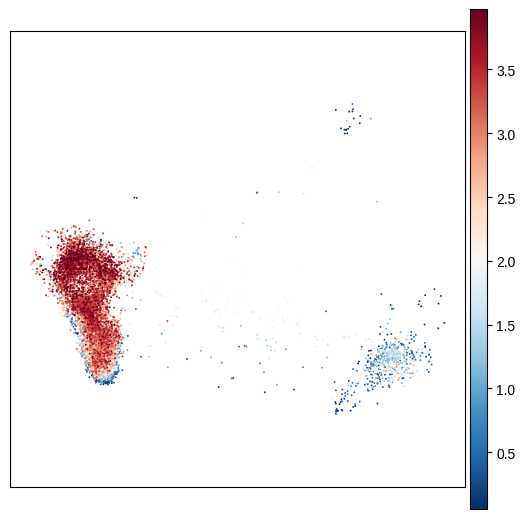

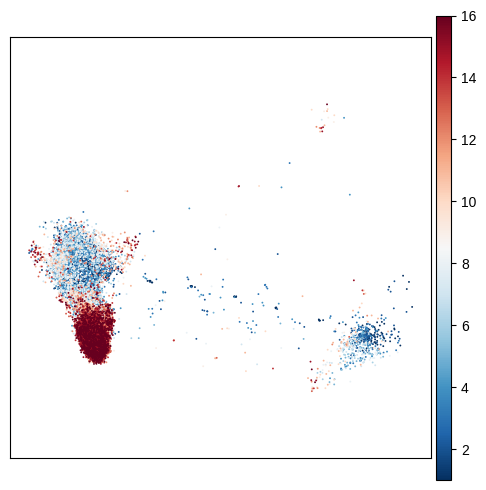

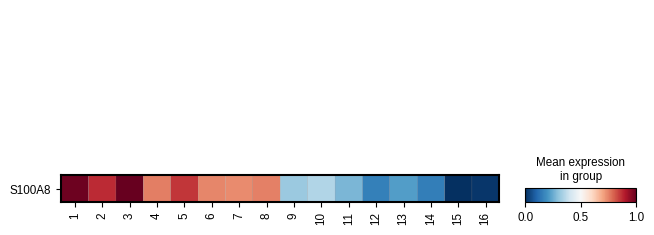

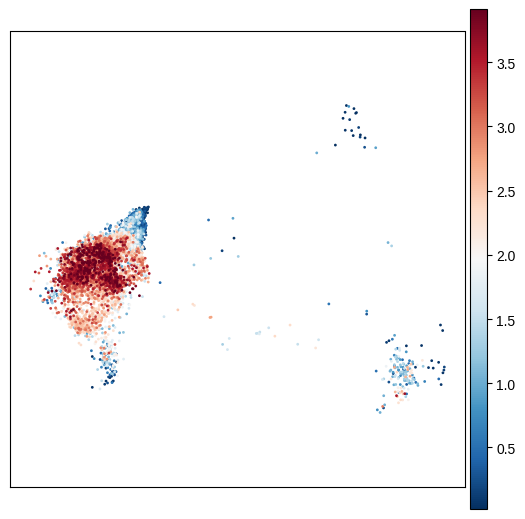

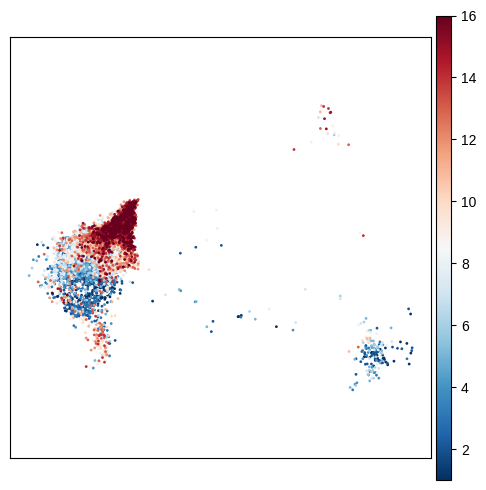

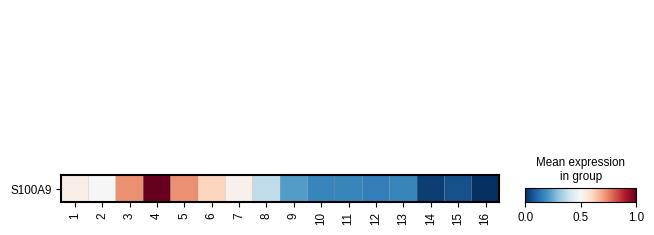

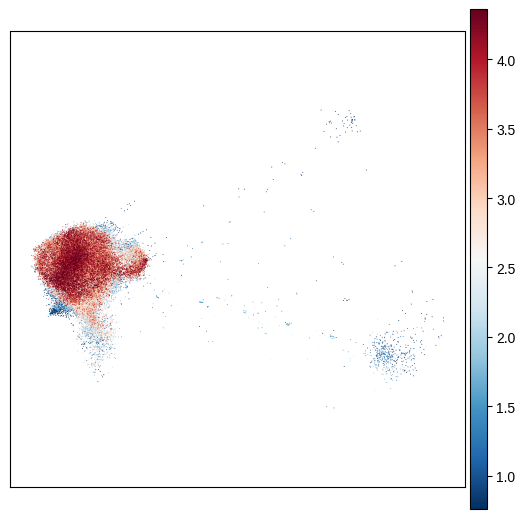

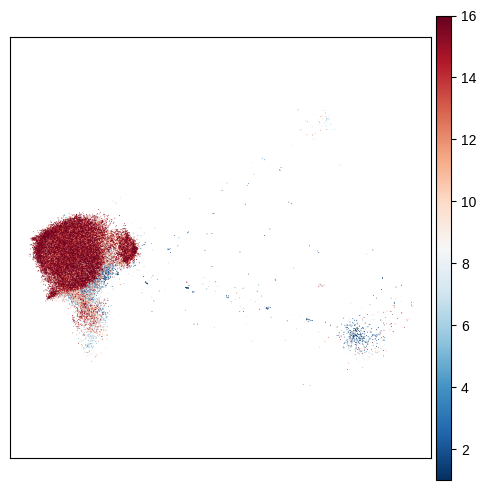

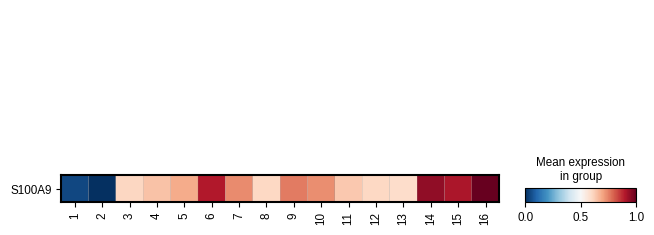

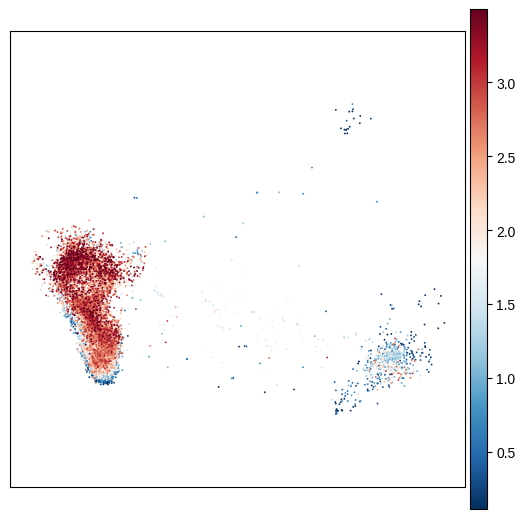

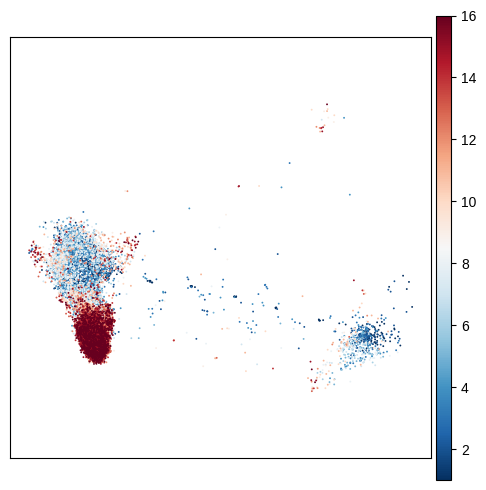

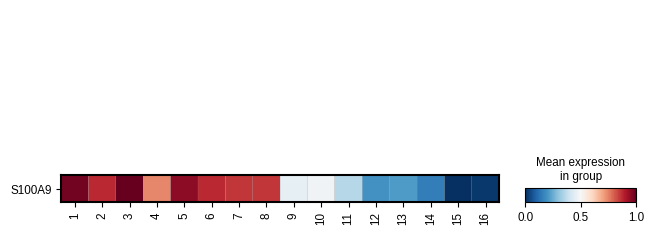

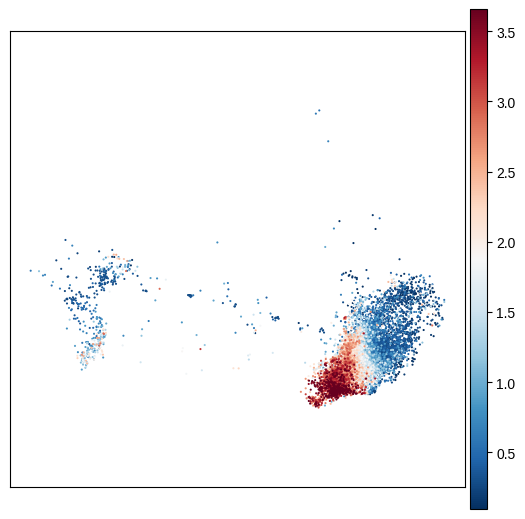

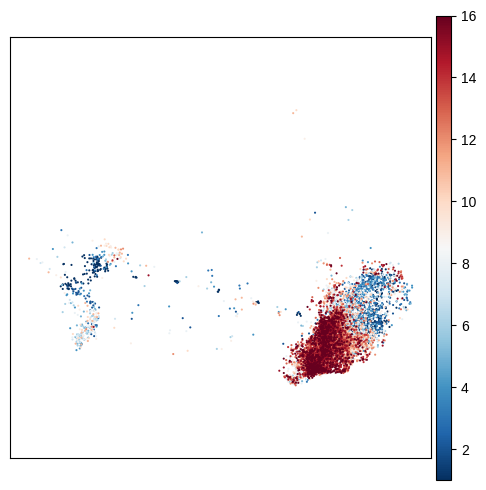

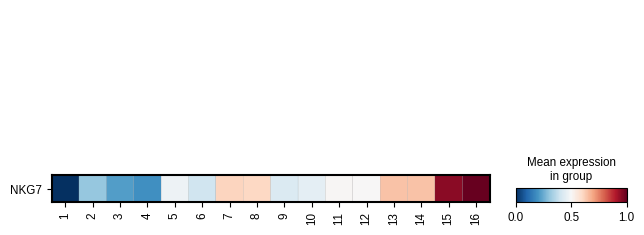

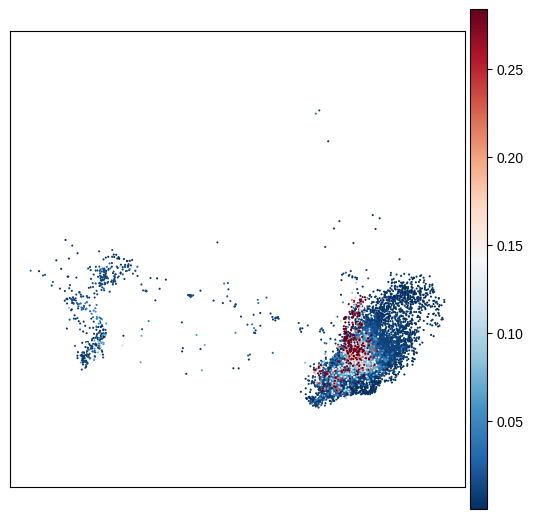

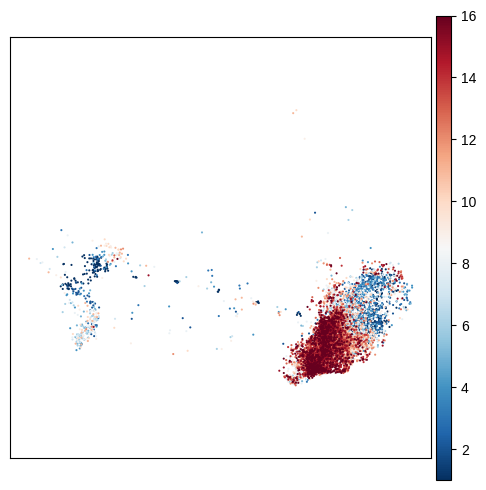

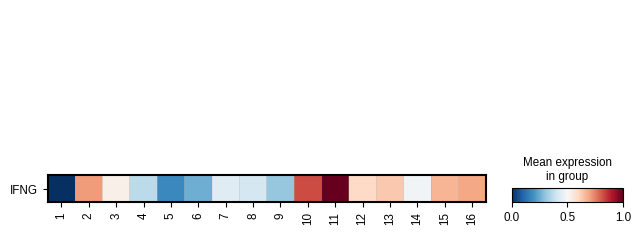

In [11]:
for gtp, cell_types in genes_to_plot.items():
    
    save_path = f'{FIG_ROOT}/{dataset_name.capitalize()}/gene_vis/{gtp}'
    os.makedirs(save_path, exist_ok=True)
    
    if not gtp in adata.var_names:
        print(f'{gtp} absent from var_names')
        continue

    for ctype in cell_types:
        if isinstance(ctype, str):
            mask = adata.obs[cell_type_key]==ctype
            mask_emb = adata_all.obs[cell_type_key]==ctype
        elif isinstance(ctype, tuple):
            mask = adata.obs[cell_type_key].isin(ctype)
            mask_emb = adata_all.obs[cell_type_key].isin(ctype)
            ctype = str(ctype).replace(',','-')

        # UMAP gene
        fig, ax = plt.subplots(figsize=(5, 5))
        sc.pl.embedding(
            adata_all[mask_emb],
            ax=ax,
            basis='X_umap_fit',
            color=gtp,
            cmap='RdBu_r',
            vmin='p2',
            vmax='p98',
            show=False,
        )
        ax.set_aspect('equal')
        ax.set_box_aspect(1)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title('')
        for coll in ax.collections:
            coll.set_rasterized(True)
        plt.tight_layout()
        plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
        
        plt.savefig(f'{save_path}/{gtp}_{ctype}.svg', dpi=500, bbox_inches='tight')
        
        # # UMAP level
        fig, ax = plt.subplots(figsize=(5, 5))
        sc.pl.embedding(
            adata_all[mask_emb],
            ax=ax,
            basis='X_umap_fit',
            color='level',
            cmap='RdBu_r',
            show=False,
        )
        ax.set_aspect('equal')
        ax.set_box_aspect(1)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title('')
        for coll in ax.collections:
            coll.set_rasterized(True)
        plt.tight_layout()
        
        plt.savefig(f'{save_path}/level_{ctype}.svg', dpi=500, bbox_inches='tight')
        
        # Heatmap
        sc.pl.matrixplot(
            adata=adata[mask],
            var_names=[gtp],
            groupby='level_cat',
            swap_axes=True,
            cmap='RdBu_r',
            show=False,
            standard_scale='var',
            )
        
        plt.savefig(f'{save_path}/mtxplot_{ctype}.svg', dpi=500, bbox_inches='tight')

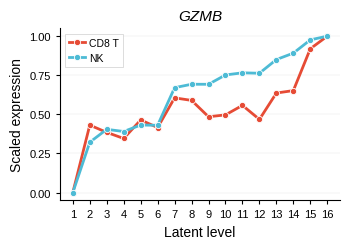

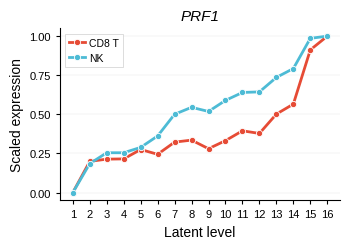

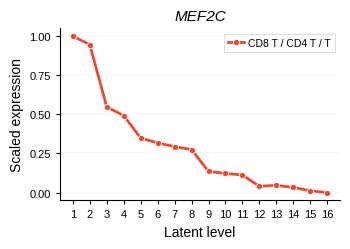

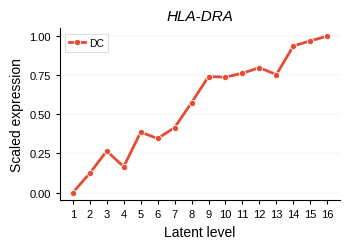

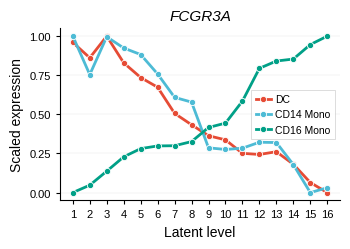

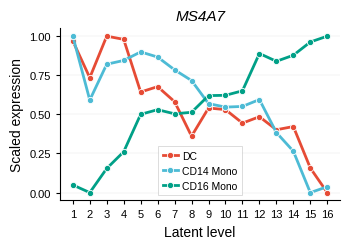

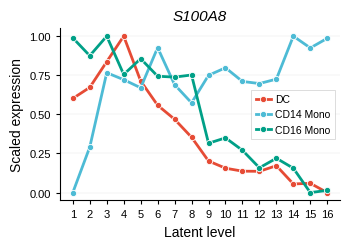

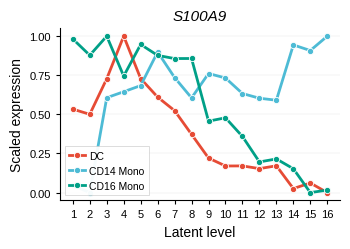

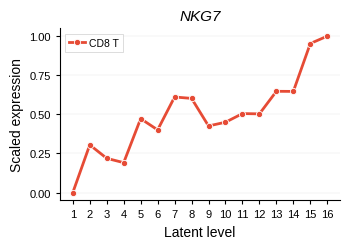

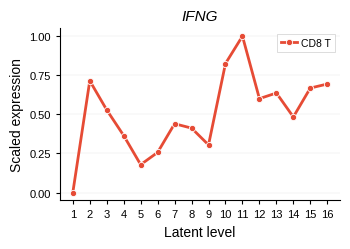

In [12]:
PALETTE = [
    '#E64B35',  # vermilion
    '#4DBBD5',  # sky
    '#00A087',  # teal
    '#3C5488',  # indigo
    '#F39B7F',  # salmon
    '#8491B4',  # steel
    '#91D1C2',  # mint
    '#DC9E82',  # clay
]

def _mean_expr(ad, gene):
    x = ad[:, gene].X
    if hasattr(x, 'toarray'):
        x = x.toarray()
    return float(np.asarray(x).ravel().mean())

for gtp, cell_types in genes_to_plot.items():

    save_path = f'{FIG_ROOT}/{dataset_name.capitalize()}/gene_vis/{gtp}'
    os.makedirs(save_path, exist_ok=True)

    if gtp not in adata.var_names:
        print(f'{gtp} absent from var_names')
        continue

    levels = sorted(adata.obs['level_cat'].cat.categories, key=lambda x: int(x))

    # mean lognorm exp per level
    records = {}
    for ctype in cell_types:
        if isinstance(ctype, str):
            mask = adata.obs[cell_type_key] == ctype
            label = ctype
        else:
            mask = adata.obs[cell_type_key].isin(ctype)
            label = ' / '.join(ctype)
        records[label] = np.array([
            _mean_expr(adata[mask & (adata.obs['level_cat'] == lv)], gtp)
            for lv in levels
        ])

    # scale 0 - 1
    for k in records:
        lo, hi = records[k].min(), records[k].max()
        records[k] = (records[k] - lo) / (hi - lo + 1e-12)

    # plotting
    fig, ax = plt.subplots(figsize=(3.6, 2.6))
    x = np.arange(len(levels))

    for idx, (label, vals) in enumerate(records.items()):
        c = PALETTE[idx % len(PALETTE)]
        ax.plot(x, vals, '-o', color=c, lw=2, ms=4.5,
                markeredgecolor='white', markeredgewidth=0.6,
                label=label, zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels([str(l) for l in levels], fontsize=8)
    ax.set_xlabel('Latent level', fontsize=10, labelpad=4)
    ax.set_ylabel('Scaled expression', fontsize=10, labelpad=4)
    ax.set_title(gtp, fontsize=11, fontstyle='italic', pad=6)
    ax.set_ylim(-0.05, 1.05)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25))

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.tick_params(axis='both', length=3, width=0.8, labelsize=8)
    ax.yaxis.grid(True, lw=0.3, alpha=0.5, color='#cccccc')
    ax.set_axisbelow(True)

    leg = ax.legend(fontsize=7.5, frameon=True, fancybox=False,
                    edgecolor='#cccccc', framealpha=0.95,
                    loc='best', handlelength=1.5, handletextpad=0.4)
    leg.get_frame().set_linewidth(0.5)

    plt.tight_layout()
    plt.savefig(f'{save_path}/lineplot_{gtp}.svg', dpi=500, bbox_inches='tight')
    plt.savefig(f'{save_path}/lineplot_{gtp}.pdf', dpi=500, bbox_inches='tight')

# UMAPs of progressive latent

In [13]:
save_path = f'{FIG_ROOT}/{dataset_name.capitalize()}/UMAPS'
os.makedirs(save_path, exist_ok=True)
condition_name = 'condition'

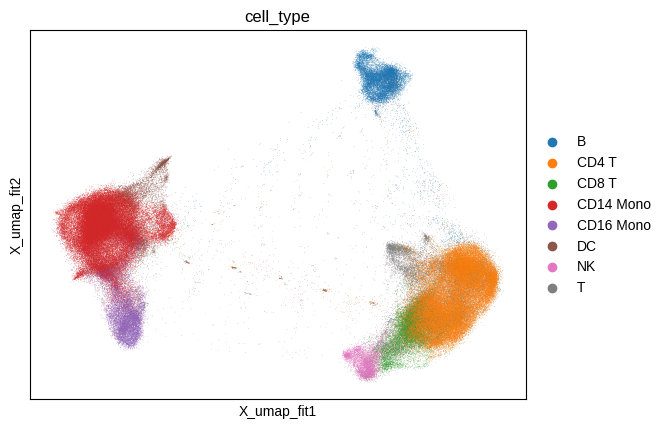

In [14]:
sc.pl.embedding(
    adata_all,
    basis='X_umap_fit',
    color=cell_type_key,
    show=False
)

plt.savefig(f'{save_path}/UMAP_cat_cell_type.png', dpi=600)
plt.savefig(f'{save_path}/UMAP_cat_cell_type.svg', dpi=600, bbox_inches='tight')

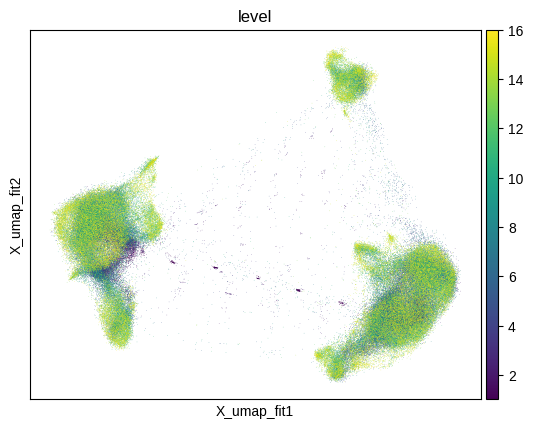

In [15]:
sc.pl.embedding(
    adata_all,
    basis='X_umap_fit',
    color='level',
    show=False
)

plt.savefig(f'{save_path}/UMAP_cat_level.png', dpi=600)
plt.savefig(f'{save_path}/UMAP_cat_level.svg', dpi=600, bbox_inches='tight')

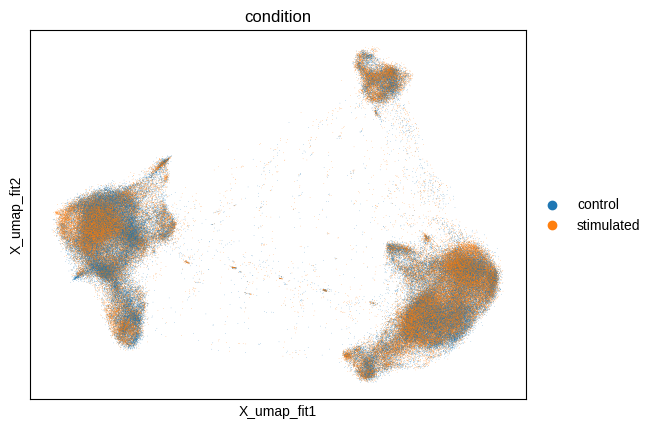

In [16]:
sc.pl.embedding(
    adata_all,
    basis='X_umap_fit',
    color=condition_name,
    show=False
)

plt.savefig(f'{save_path}/UMAP_cat_condition.png', dpi=600)
plt.savefig(f'{save_path}/UMAP_cat_condition.svg', dpi=600, bbox_inches='tight')

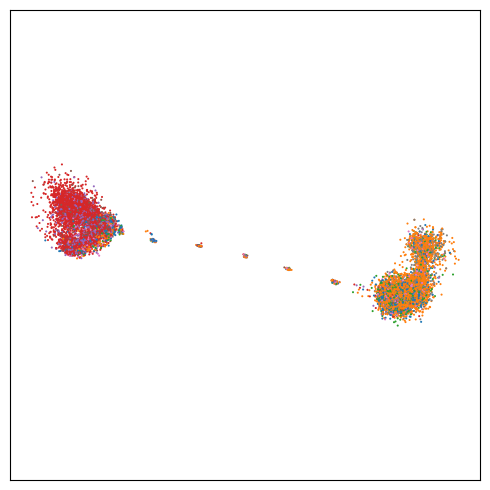

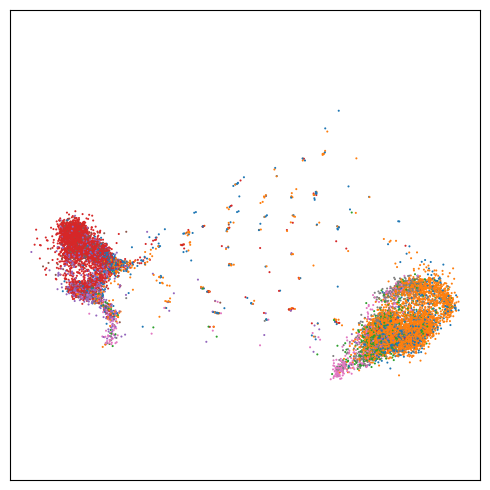

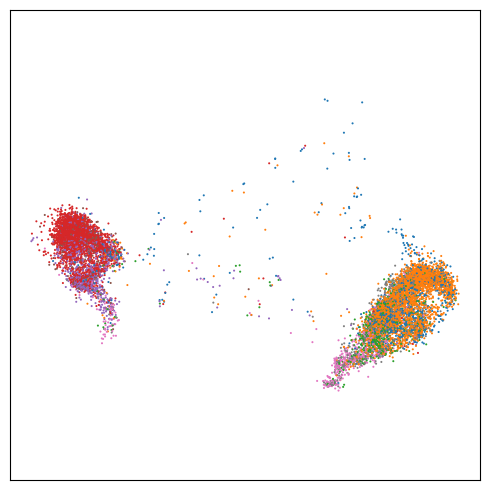

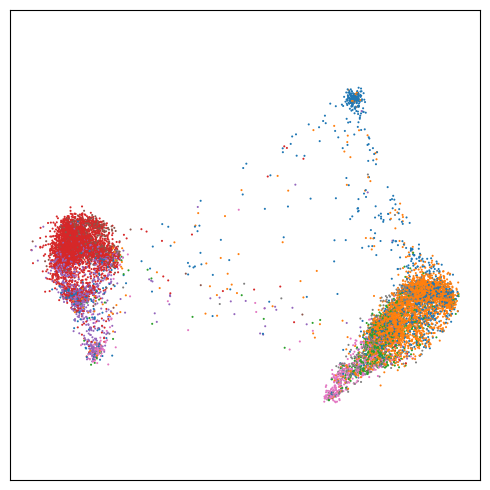

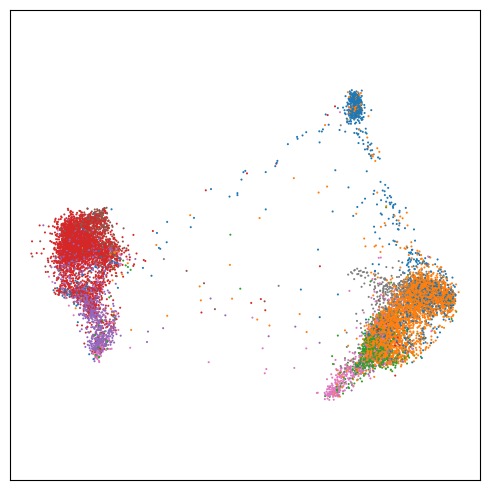

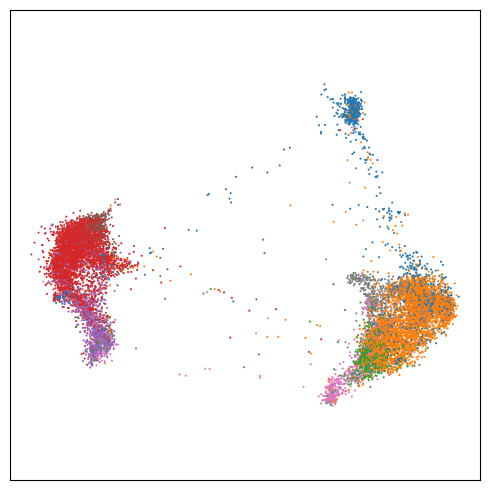

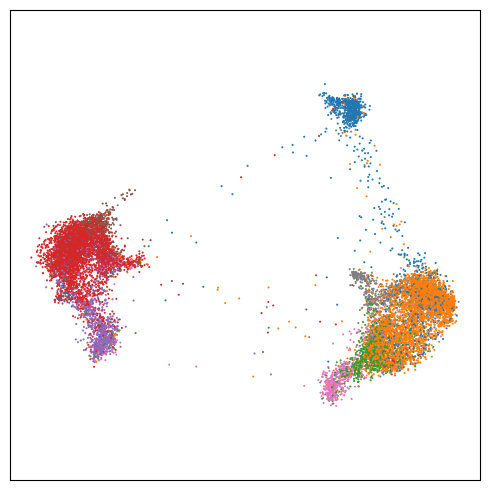

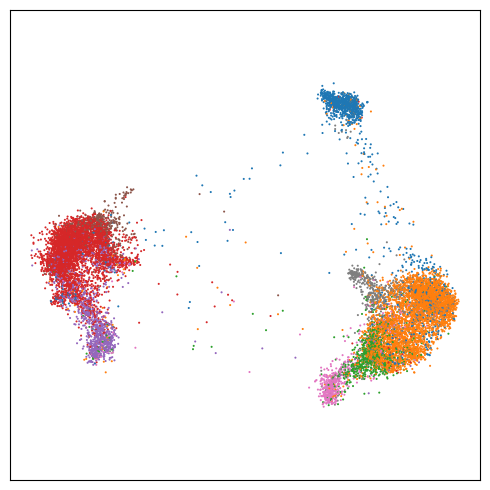

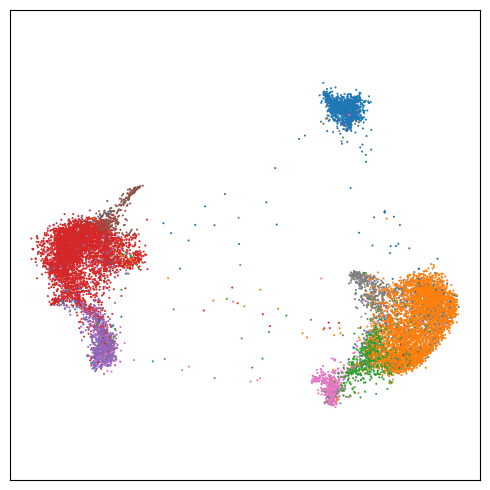

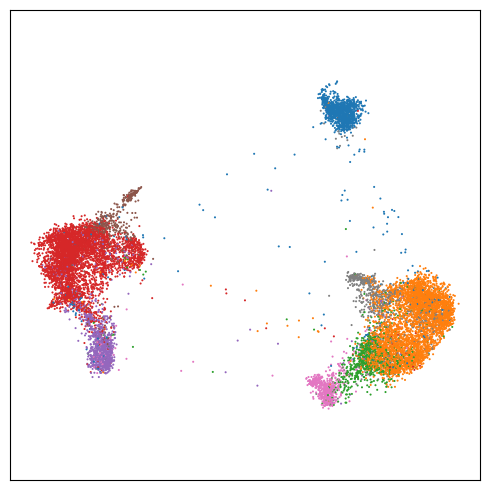

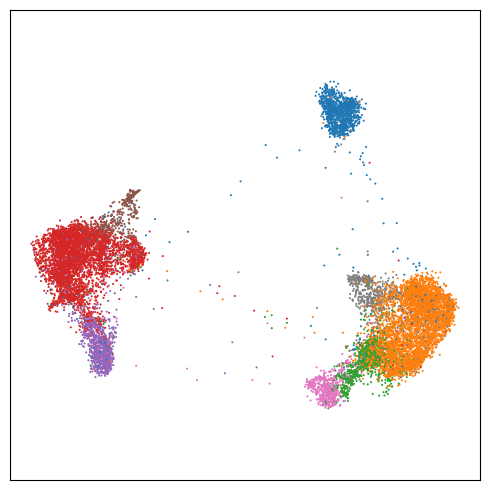

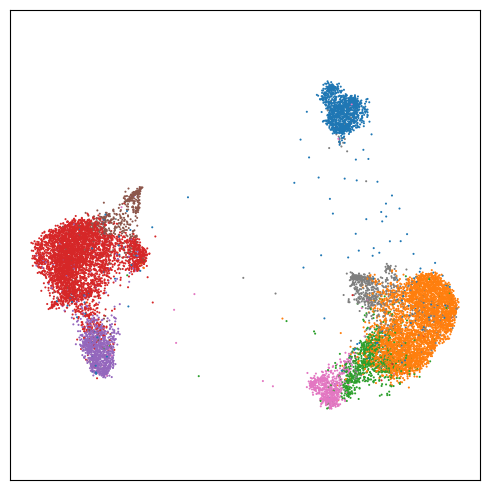

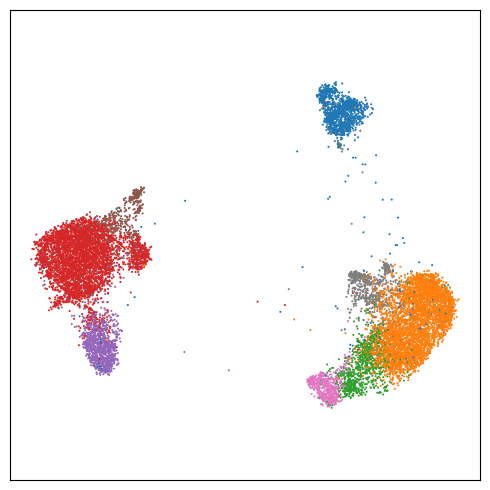

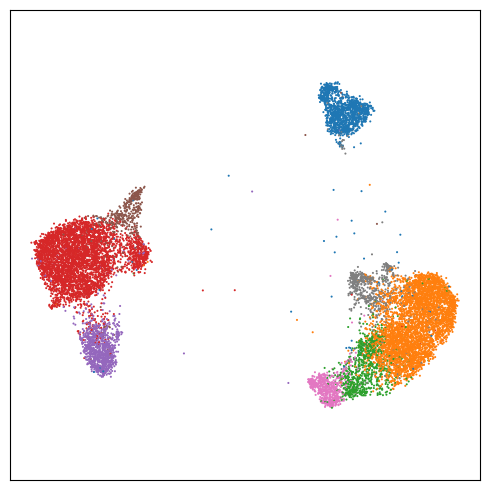

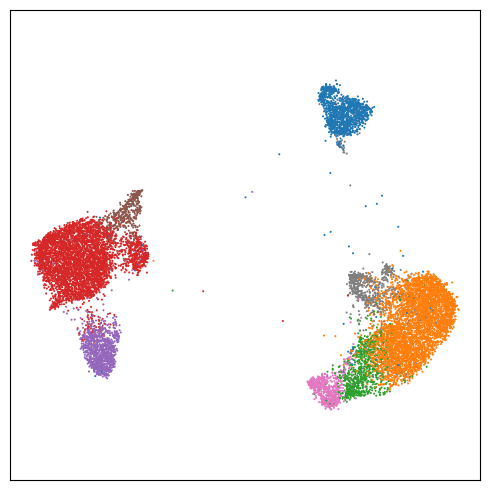

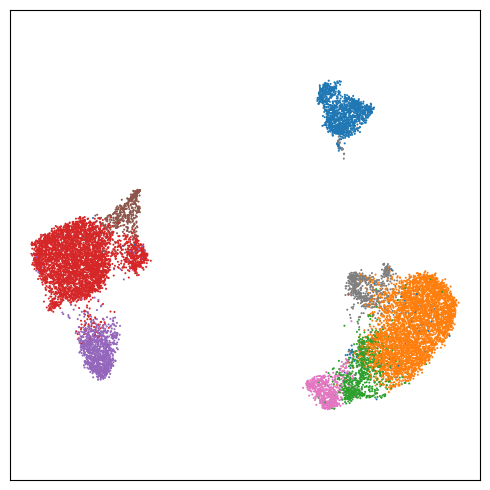

In [17]:
umap_path = f'{save_path}/{cell_type_key}'
os.makedirs(umap_path, exist_ok=True)

for level in range(1, 17):
    
    _adata = adata_all[adata_all.obs['level'] == level]
    fig, ax = plt.subplots(figsize=(5,5))
    sc.pl.embedding(
        _adata, 
        basis='X_umap_fit', 
        color=cell_type_key, 
        show=False, 
        ax=ax, 
        legend_loc=None
    )
    ax.set_aspect('equal')
    ax.set_box_aspect(1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title('')
    for coll in ax.collections:
        coll.set_rasterized(True)
    plt.tight_layout()
    #plt.savefig(f'{umap_path}/map_latent_{level}.png', dpi=500, bbox_inches='tight')
    plt.savefig(f'{umap_path}/map_latent_{level}.svg', dpi=500, bbox_inches='tight')

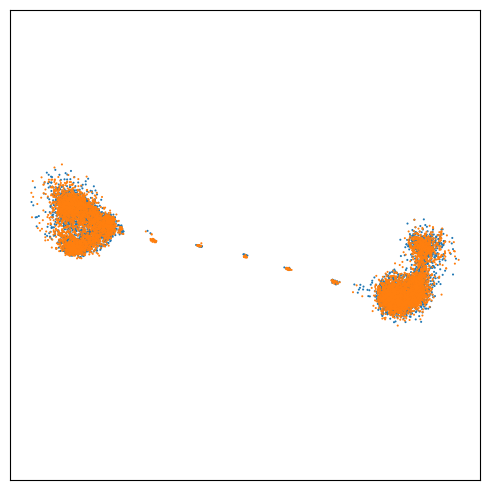

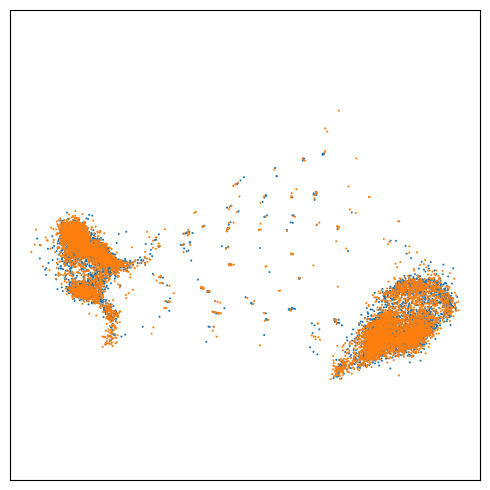

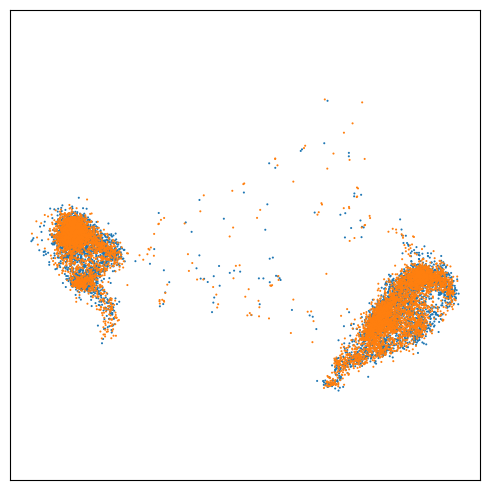

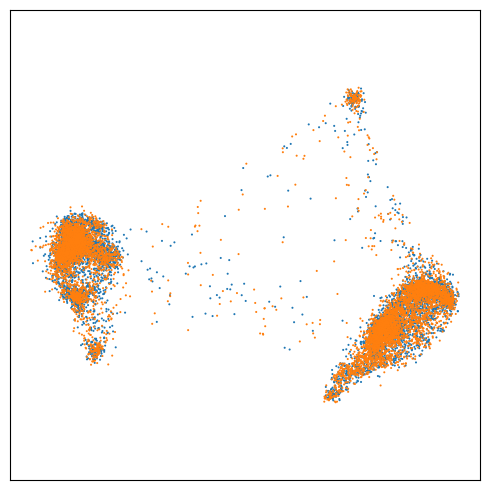

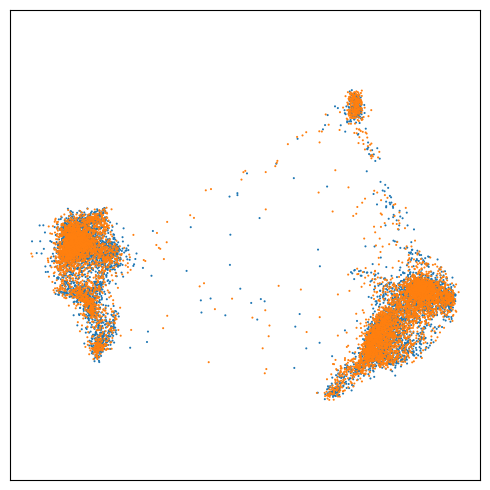

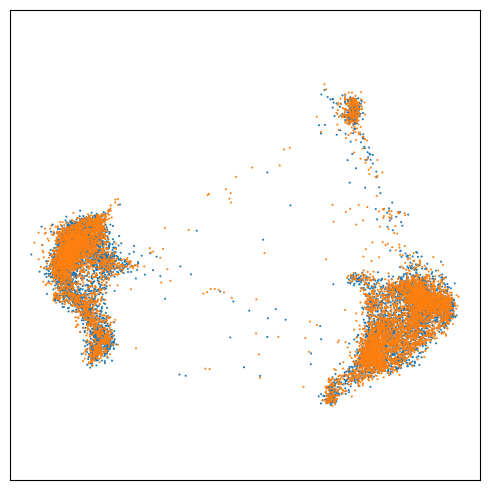

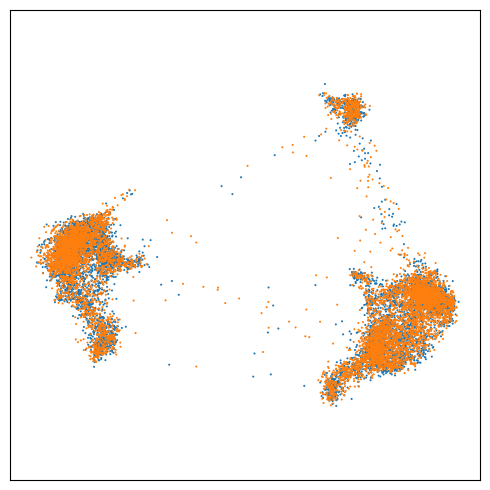

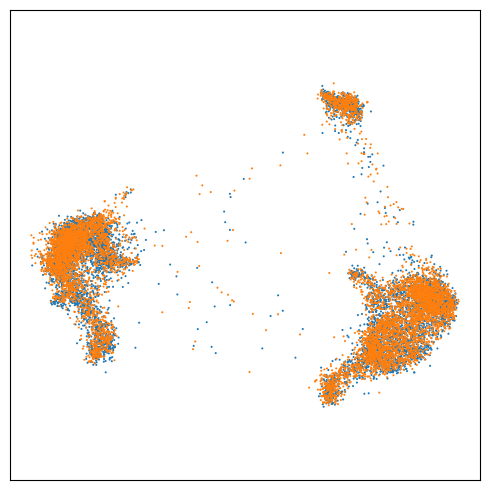

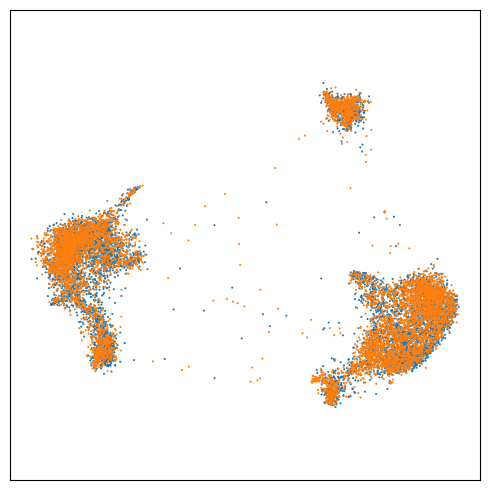

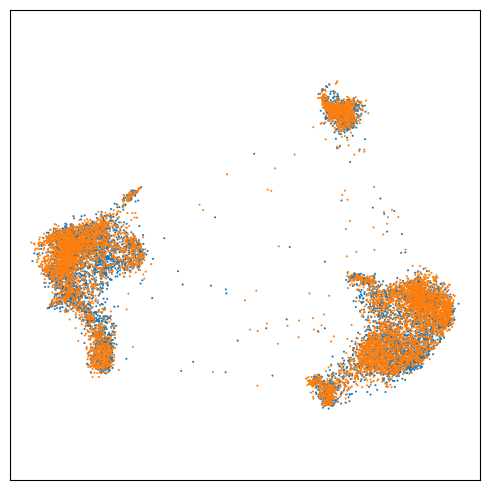

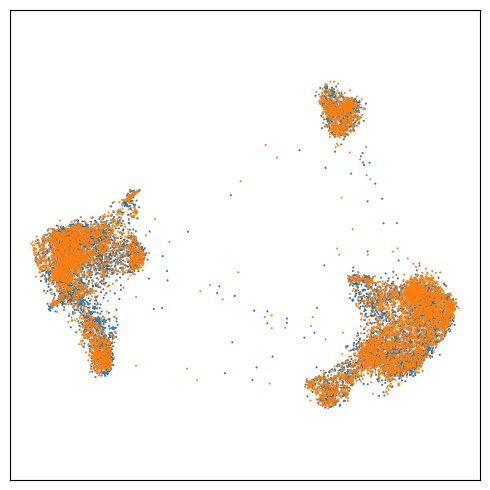

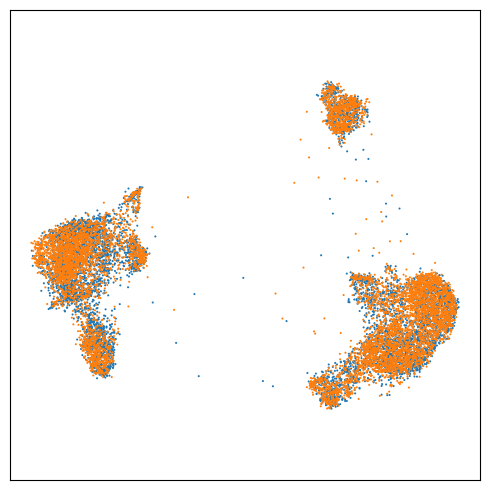

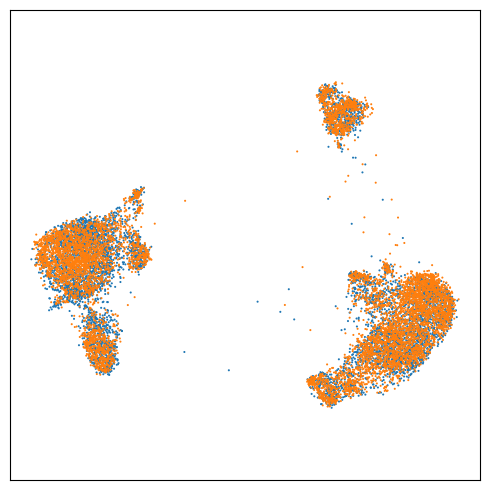

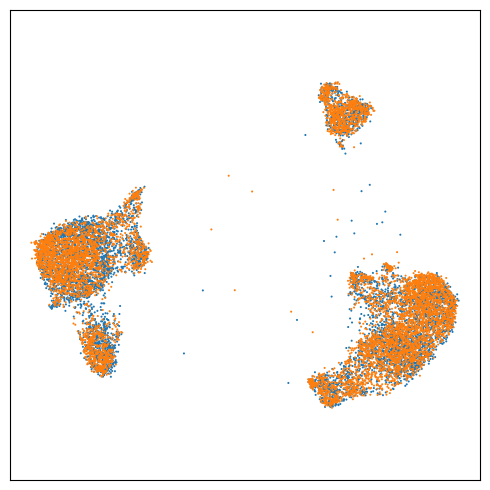

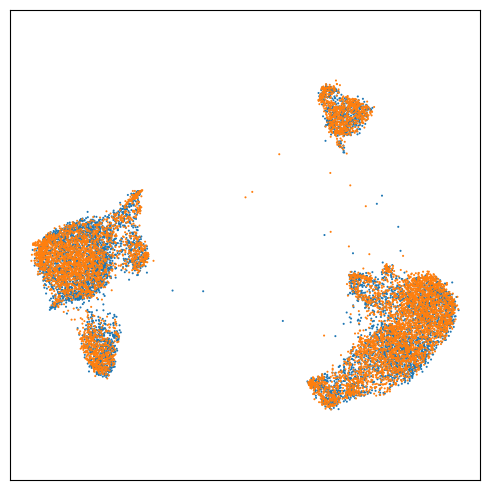

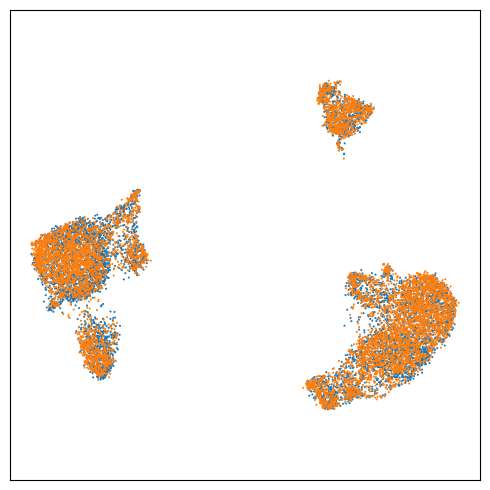

In [18]:
umap_path = f'{save_path}/{condition_name}'
os.makedirs(umap_path, exist_ok=True)

for level in range(1, 17):
    
    _adata = adata_all[adata_all.obs['level'] == level]
    fig, ax = plt.subplots(figsize=(5,5))
    sc.pl.embedding(
        _adata, 
        basis='X_umap_fit', 
        color=f'{condition_name}', 
        show=False, 
        ax=ax,
        legend_loc=None
    )
    ax.set_aspect('equal')
    ax.set_box_aspect(1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title('')
    for coll in ax.collections:
        coll.set_rasterized(True)
    plt.tight_layout()
    #plt.savefig(f'{umap_path}/map_latent_{level}.png', dpi=500, bbox_inches='tight')
    plt.savefig(f'{umap_path}/map_latent_{level}.svg', dpi=500, bbox_inches='tight')